In [1]:
# Bibliotecas #

from Filtro_LS import filtro_LS1
from Filtro_LS import filtro_LS10
from Filtro_LMS import filtro_LMS1 as filtro_LMS_1
from Funcoes_auxiliares import *
from Gerador_de_Sinais import main as leitura_shaper
from Gerador_de_Sinais import original_signal_generator

In [2]:
# Consantes & Variáveis #
quantidade_de_amostras = 1500

seed = None  # 73

In [30]:
# aplicando_filtro_em_outro_readout
def aplicando_filtro_em_outro_readout(quant_de_amostras, pesos, bias, ordem_filtro1=7):
    """
    Usa pesos e bias calculados previamente em um sinal novo.
    """
    # Sinal novo #
    sinal_original_2 = original_signal_generator(quant_de_amostras, seed=None)
    Readout_Shaper_2 = leitura_shaper(sinal_original_2, seed=None)

    # aplicando filtro #

    # Sinal Estimado/Recuperado
    sinal_estimado_2 = np.zeros(len(Readout_Shaper_2))

    # Tamanho do sinal estimado
    len_sinal_estimado = len(Readout_Shaper_2) - ordem_filtro1 + 1
    print(f"{len_sinal_estimado = }")

    # Parte adaptativa do filtro
    for i in range(len_sinal_estimado):
        sinal_estimado_2[i] = (
            np.dot(Readout_Shaper_2[i : i + ordem_filtro1], pesos) + bias
        )

    _ = RMSE_e_MAE_por_ordem(
        A=sinal_estimado_2[:len_sinal_estimado],
        B=sinal_original_2[:len_sinal_estimado],
        ordem_filtro=ordem_filtro1,
        printar=True,
    )

    plot_estimado_x_original(
        sinal_original_2[:len_sinal_estimado],
        estimado=sinal_estimado_2[:len_sinal_estimado],
        ordem=ordem_filtro1,
        title="Original x Pesos de outro sinal",
    )


#


def busca_delay_e_ordem(
    sinal_original1, Readout_Shaper1, filtro, delays=range(0, 10), ordens=range(3, 20)
):
    """
    return ordem_menor_r, delay_menor_r
    """
    # ordens = range(3, 20)
    # delays=range(0,10)
    r_min = 99

    for delay2 in delays:
        for ordem in ordens:
            sinal_estimado1, *_ = filtro(
                sinal_desejado=sinal_original1,
                readout=Readout_Shaper1,
                ordem_filter=ordem,
                delay=delay2,
            )
            # print(f"Ordem do filtro: {ordem}")
            r_2, _ = RMSE_e_MAE_por_ordem(
                A=sinal_estimado1,
                B=sinal_original1,
                ordem_filtro=ordem,
                printar=False,
            )
            # print()

            if r_2 < r_min:
                r_min = r_2
                ordem_menor_r = ordem
                delay_menor_r = delay2

    print(f"Ordem do filtro com menor RMSE: {ordem_menor_r}")
    print(f"Delay do filtro com menor RMSE: {delay_menor_r}")

    return ordem_menor_r, delay_menor_r


#

In [4]:
# Gerador de sinais #
sinal_original1 = original_signal_generator(quantidade_de_amostras, seed=seed)
Readout_Shaper1 = leitura_shaper(sinal_original1, seed=seed)

# Filtro LS

In [5]:
# Melhor ordem #
ordens = range(3, 20)
r_min = 99

for ordem in ordens:
    sinal_estimado1, *_ = filtro_LS1(
        sinal_desejado=sinal_original1,
        readout=Readout_Shaper1,
        ordem_filter=ordem,
    )

    r_2, m_2 = RMSE_e_MAE_por_ordem(
        A=sinal_estimado1,
        B=sinal_original1,
        ordem_filtro=ordem,
        printar=False,
    )

    if r_2 < r_min:
        r_min = r_2
        ordem_menor_r = ordem

print(f"Ordem do filtro com menor RMSE: {ordem_menor_r}")

Ordem do filtro com menor RMSE: 7


erro_abs_medio = 1.1980
rmse = 2.1113


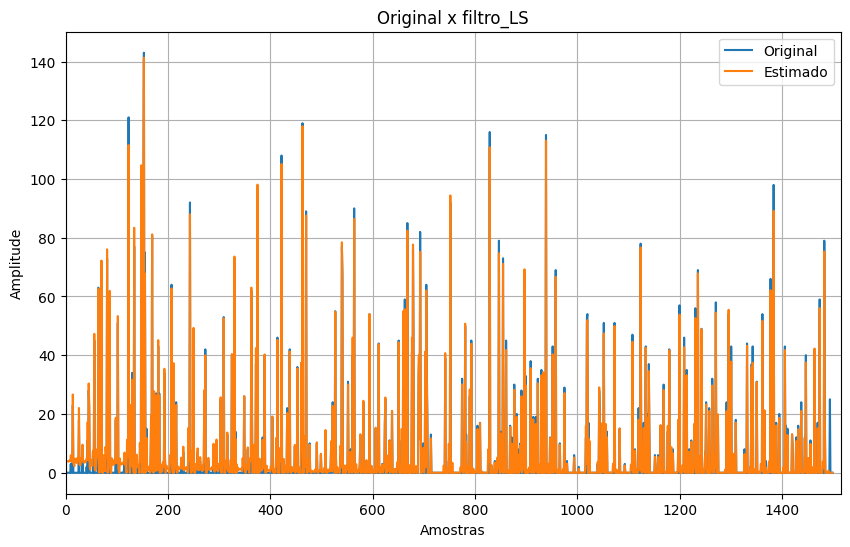

In [6]:
# Filtro 1 #

sinal_estimado1, pesos1, bias1 = filtro_LS1(
    sinal_desejado=sinal_original1,
    readout=Readout_Shaper1,
    ordem_filter=ordem_menor_r,
)

r_2, m_2 = RMSE_e_MAE_por_ordem(
    A=sinal_estimado1,
    B=sinal_original1,
    ordem_filtro=ordem_menor_r,
    printar=True,
)

plot_estimado_x_original(
    sinal_original1,
    estimado=sinal_estimado1,
    ordem=ordem_menor_r,
    title="Original x filtro_LS",
)

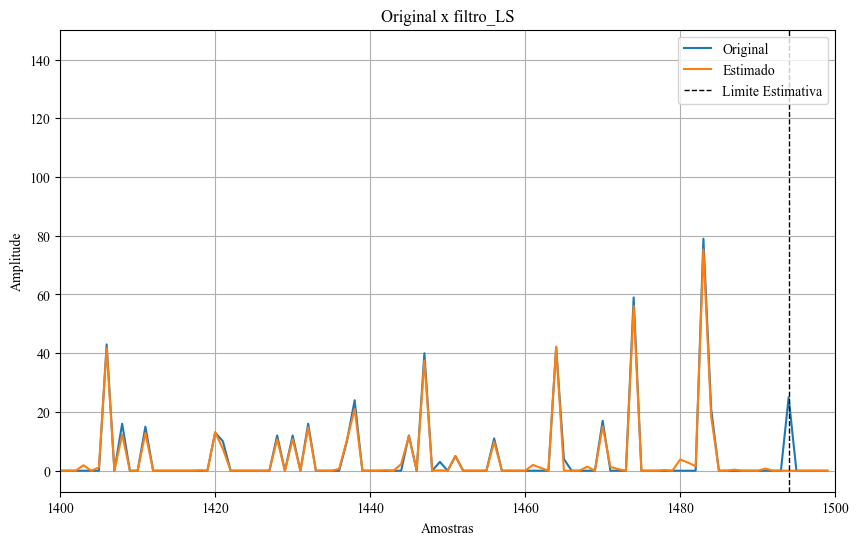

In [81]:
plot_estimado_x_original(
    sinal_original1,
    estimado=sinal_estimado1,
    ordem=ordem_menor_r,
    title="Original x filtro_LS",
    xlimite_max=1500,
    xlimite_min=1400,
    limite_filtro=True,
)

In [7]:
# # Aplicando pesos calculados em um sinal nao visto antes #

# # sinal novo
# if seed is not None:
#     seed += 9


# aplicando_filtro_em_outro_readout(quantidade_de_amostras, pesos1, bias1)

# Filtro LMS

In [8]:
# ordens = range(3, 20)
# r_min = 99
# delays = range(0, 10)

# for delay2 in delays:
#     for ordem in ordens:
#         sinal_estimado1, *_ = filtro_LMS_1(
#             sinal_desejado=sinal_original1,
#             readout=Readout_Shaper1,
#             ordem_filter=ordem,
#             delay=delay2,
#         )
#         # print(f"Ordem do filtro: {ordem}")
#         r_2, m_2 = RMSE_e_MAE_por_ordem(
#             A=sinal_estimado1,
#             B=sinal_original1,
#             ordem_filtro=ordem,
#             printar=False,
#         )
#         # print()

#         if r_2 < r_min:
#             r_min = r_2
#             ordem_menor_r = ordem
#             delay_menor_r = delay2

# print(f"Ordem do filtro com menor RMSE: {ordem_menor_r}")
# print(f"Delay do filtro com menor RMSE: {delay_menor_r}")

In [9]:
ordem_lms, delay_lms = busca_delay_e_ordem(
    sinal_original1, Readout_Shaper1, filtro_LMS_1
)

Ordem do filtro com menor RMSE: 8
Delay do filtro com menor RMSE: 0


erro_abs_medio = 0.7987
rmse = 2.4981


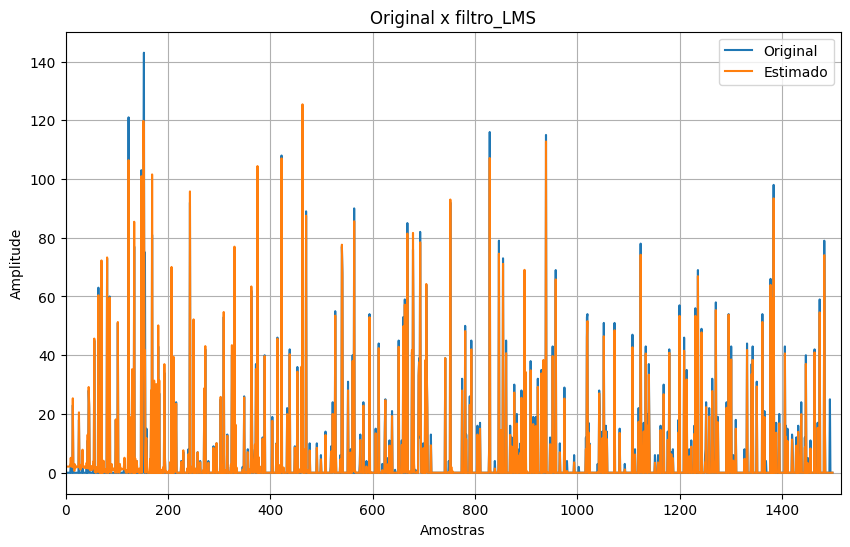

In [43]:
ordem_lms = 8
delay_lms = 0

sinal_estimado2, pesos2, bias2 = filtro_LMS_1(
    sinal_desejado=sinal_original1,
    readout=Readout_Shaper1,
    ordem_filter=ordem_lms,
    delay=delay_lms,
    # n_epocas=10,
    # mu=0.00006,
    n_epocas=10,
    mu=0.00006,
)
r_3, m_3 = RMSE_e_MAE_por_ordem(
    A=sinal_estimado2,
    B=sinal_original1,
    ordem_filtro=ordem_lms,
    printar=True,
)

plot_estimado_x_original(
    sinal_original1,
    estimado=sinal_estimado2,
    ordem=ordem_lms,
    title="Original x filtro_LMS",
)

In [ ]:
# # Aplicando pesos calculados em um sinal nao visto antes #

# # sinal novo
# if seed is not None:
#     seed += 9


aplicando_filtro_em_outro_readout(
    quantidade_de_amostras, pesos2, bias2, ordem_filtro1=8
)

# comparaçao

In [ ]:
plot_estimado_x_original(
    sinal_original1,
    estimado=sinal_estimado2,
    ordem=ordem_lms,
    title="Original x filtro_LMS",
    xlimite_max=1000,
    xlimite_min=925,
)

In [78]:
def plot_ls_lms_lado_a_lado_zoom(
    original,
    estimado_ls,
    estimado_lms,
    xlimite_min=925,
    xlimite_max=1000,
    ylimite_min=-5,
    ylimite_max=120,
    figsize=(20, 8),
    fonte_familia="Times New Roman",
    fonte_subtitulo=20,
    fonte_eixos=20,
    fonte_ticks=20,
    fonte_legenda=20,
    color_s_esti=(1.0, 0.549, 0.0),  # darkorange",
    linewidth=2,
):
    plt.rcParams["font.family"] = fonte_familia

    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # (a) LS
    axs[0].plot(original, label="Original", linewidth=linewidth)
    axs[0].plot(
        estimado_ls, label="Estimado LS", linewidth=linewidth, color=color_s_esti
    )
    axs[0].set_xlim(xlimite_min, xlimite_max)
    axs[0].set_ylim(ylimite_min, ylimite_max)
    axs[0].set_title("(a) Filtro LS com zoom", fontsize=fonte_subtitulo)
    axs[0].set_xlabel("Amostras", fontsize=fonte_eixos)
    axs[0].set_ylabel("Amplitude", fontsize=fonte_eixos)
    axs[0].tick_params(axis="both", labelsize=fonte_ticks)
    axs[0].grid(True)
    axs[0].legend(loc="upper right", fontsize=fonte_legenda)

    # (b) LMS
    axs[1].plot(original, label="Original", linewidth=linewidth)
    axs[1].plot(
        estimado_lms, label="Estimado LMS", linewidth=linewidth, color=color_s_esti
    )
    axs[1].set_xlim(xlimite_min, xlimite_max)
    axs[1].set_title("(b) Filtro LMS com zoom", fontsize=fonte_subtitulo)
    axs[1].set_xlabel("Amostras", fontsize=fonte_eixos)
    axs[1].tick_params(axis="both", labelsize=fonte_ticks)
    axs[1].grid(True)
    axs[1].legend(loc="upper right", fontsize=fonte_legenda)

    # fig.suptitle(f"Filtros LS e LMS com zoom aplicado.", fontsize=fonte_titulo)
    plt.tight_layout()
    plt.show()

In [ ]:
"""Parametros de referencia:

xlimite_min=925,
xlimite_max=1000,
ylimite_min=-5,
ylimite_max=120,
figsize=(14, 5),
fonte_familia="Times New Roman",
fonte_titulo=16,
fonte_subtitulo=13,
fonte_eixos=12,
fonte_ticks=11,
fonte_legenda=11,"""

In [ ]:
fonte = 25
plot_ls_lms_lado_a_lado_zoom(
    original=sinal_original1,
    estimado_ls=sinal_estimado1,
    estimado_lms=sinal_estimado2,
    linewidth=5,
    fonte_subtitulo=fonte,
    fonte_eixos=fonte,
    fonte_ticks=fonte,
    fonte_legenda=fonte,
)